In [100]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ast


In [101]:
filepath = "./simulation_data_2_particles.csv"
df = pd.read_csv(filepath)

In [102]:
df.head()

,simulation_id,time,x,V
0,0,0.000,"[0.3909068595733095, 0.4623964528319734]",0.000903
1,0,0.001,"[0.3909013844603707, 0.462427364010273]",0.000895
2,0,0.002,"[0.3908956968589201, 0.4624584876770844]",0.000888
3,0,0.003,"[0.390889797678615, 0.46248982292275037]",0.000880
4,0,0.004,"[0.39088368783973704, 0.46252136882698913]",0.000872


In [ ]:
x = df['x'].tolist()
# TODO: replace with V
E = df['V'].tolist()

for xi, Ei in zip(x, E):
    # not using the right positions of the particles
    all_samples.append({"x": ast.literal_eval(xi), "E": float(Ei)})
    
    break

[0.3909068595733095, 0.4623964528319734] 0.0009030273530389


In [103]:

def create_simulation_video(df, simulation_id, frames, path_prefix):
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    fig, ax = plt.subplots()
    scat = ax.scatter([], [], s=80)

    ax.set_xlim(-1, 1)   
    ax.set_ylim(-0.2, 0.2)  
    ax.set_yticks([])

    def init():
        scat.set_offsets(np.empty((0, 2)))
        return (scat,)

    def update(frame):
        xs = ast.literal_eval(df[df["simulation_id"] == simulation_id]['x'].iloc[frame])
        # print('xs', xs)
        ys = [0] * len(xs)
        scat.set_offsets(np.c_[xs, ys])
        scat.set_facecolors(colors[:len(xs)])
        return (scat,)

    ani = FuncAnimation(fig, update, frames=frames,
                                init_func=init, blit=True, interval=20)

    ani.save(path_prefix + "_"+ str(simulation_id) +".mp4", writer="ffmpeg", fps=30)

In [104]:
# create_simulation_video(df, 0, 2000, "./simulations/two_particle_sim")

In [105]:
# for i in range(2):
#     create_simulation_video(df, i, 1000, "./simulations/two_particle_sim")

In [108]:
def plot_graph(df, simulation_id):

    positions = [ast.literal_eval(pos) for pos in df[df["simulation_id"] == simulation_id]['x'].tolist()]
    t = list(range(len(positions)))
    print('positions', positions)

    p0_positions = [el[0] for el in positions]
    p1_positions = [el[1] for el in positions]
    print(p0_positions)

    plt.plot(t, p0_positions, label="Particle 0")
    plt.plot(t, p1_positions, label="Particle 1")
    plt.xlabel("Time")
    plt.ylabel("xs")
    plt.legend()
    plt.show()



positions [[0.3909068595733095, 0.4623964528319734], [0.3909013844603707, 0.462427364010273], [0.3908956968589201, 0.4624584876770844], [0.390889797678615, 0.46248982292275037], [0.39088368783973704, 0.46252136882698913], [0.3908773682731469, 0.4625531244589401], [0.3908708399202382, 0.4625850888772096], [0.3908641037328908, 0.4626172611299178], [0.3908571606734241, 0.4626496402547453], [0.39085001171454903, 0.4626822252789812], [0.3908426578393202, 0.4627150152195708], [0.39083510004108724, 0.4627480090831646], [0.3908273393234455, 0.46278120586616717], [0.3908193767001865, 0.46281460455478696], [0.3908112131952478, 0.4628482041250865], [0.3908028498426622, 0.4628820035430329], [0.3907942876865066, 0.46291600176454933], [0.3907855277808502, 0.46295019773556656], [0.39077657118970244, 0.4629845903920751], [0.39076741898696027, 0.46301917866017805], [0.3907580722563549, 0.46305396145614425], [0.3907485320913981, 0.46308893768646187], [0.390738799595328, 0.4631241062478928], [0.390728875

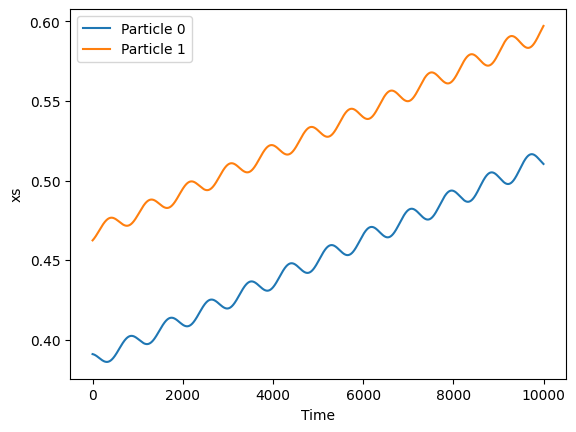

positions [[-0.4033139402826412, 0.31666999069743484], [-0.40333846789772787, 0.31665517085232336], [-0.4033492596489256, 0.3166266151433229], [-0.4033463152935401, 0.3165843233277392], [-0.4033296352756703, 0.3165282958496713], [-0.4032992207262205, 0.31645853384002337], [-0.4032550734628781, 0.31637503911648285], [-0.4031971959900571, 0.3162778141834637], [-0.40312559149880717, 0.31616686223201557], [-0.4030402638666884, 0.31604218713969867], [-0.4029412176576119, 0.315903793470424], [-0.4028284581216458, 0.3157516864742597], [-0.402701991194787, 0.3155858720872028], [-0.40256182349869885, 0.3154063569309165], [-0.4024079623404142, 0.3152131483124337], [-0.40224041571200436, 0.31500625422382567], [-0.4020591922902137, 0.3147856833418369], [-0.40186430143606017, 0.3145514450274852], [-0.4016557531944014, 0.31430354932562826], [-0.40143355829346655, 0.31404200696449525], [-0.4011977281443543, 0.3137668293551848], [-0.40094827484049606, 0.31347802859112844], [-0.4006852111570859, 0.3131

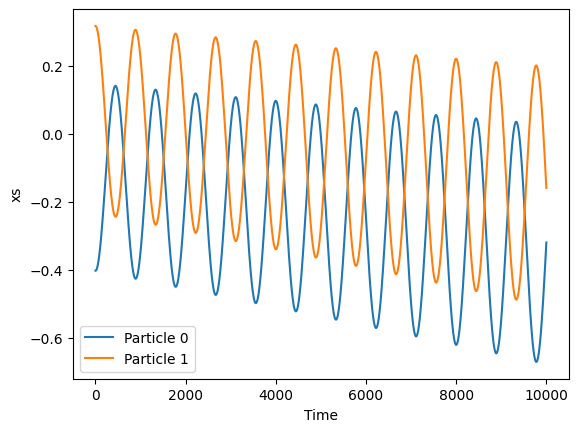

positions [[-0.2916879261769849, -0.4490154866693422], [-0.2917191198895691, -0.4489821288878743], [-0.2917573203121677, -0.44894176439639194], [-0.2918025258309934, -0.44889439480868254], [-0.29185473448192334, -0.4488400220888689], [-0.2919139439505798, -0.4487786485513287], [-0.2919801515724285, -0.4487102768605962], [-0.2920533543328944, -0.4486349100312466], [-0.2921335488674946, -0.4485525514277627], [-0.29222073146198935, -0.44846320476438417], [-0.29231489805255023, -0.44836687410493953], [-0.2924160442259458, -0.4482635638626602], [-0.2925241652197448, -0.44815327879997746], [-0.2926392559225368, -0.44803602402830167], [-0.29276131087417046, -0.44791180500778427], [-0.29289032426600886, -0.4477806275470621], [-0.2930262899412027, -0.4476424978029845], [-0.2931692013949807, -0.44749742228032274], [-0.2933190517749574, -0.4473454078314623], [-0.2934758338814583, -0.44718646165607767], [-0.29363954016786276, -0.44702059130078947], [-0.29381016274096367, -0.4468478046588048], [-0.

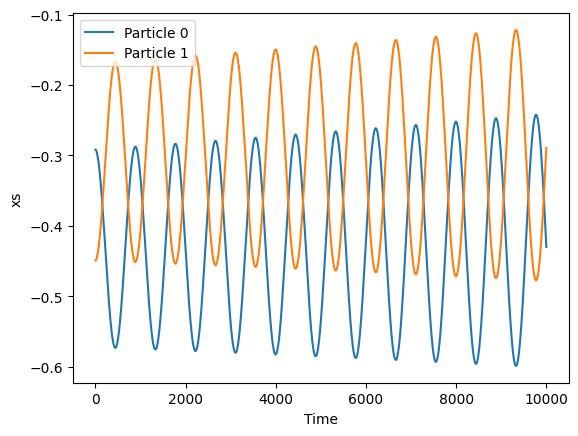

positions [[0.3030681787678925, 0.06893711582897599], [0.3030887930787476, 0.06897654577598147], [0.30310105350558325, 0.06902432960700638], [0.3031049605187904, 0.06908046685165982], [0.3031005150064541, 0.06914495662185668], [0.3030877182743302, 0.06921779761184119], [0.3030665720458007, 0.06929898809823125], [0.30303707846180866, 0.06938852594008384], [0.302999240080772, 0.06948640857898107], [0.30295305987847637, 0.0695926330391373], [0.30289854124794724, 0.06970719592752704], [0.30283568799930116, 0.06983009343403372], [0.3027645043595761, 0.06996132133161936], [0.3026849949725409, 0.0701008749765151], [0.3025971648984841, 0.07024874930843249], [0.3025010196139814, 0.07040493885079574], [0.302396565011643, 0.07056943771099469], [0.3022838073998396, 0.07074223958065869], [0.30216275350240773, 0.07092333773595115], [0.30203341045833443, 0.07111272503788506], [0.30189578582142096, 0.07131039393265907], [0.30174988755992604, 0.07151633645201456], [0.30159572405618795, 0.07173054421361

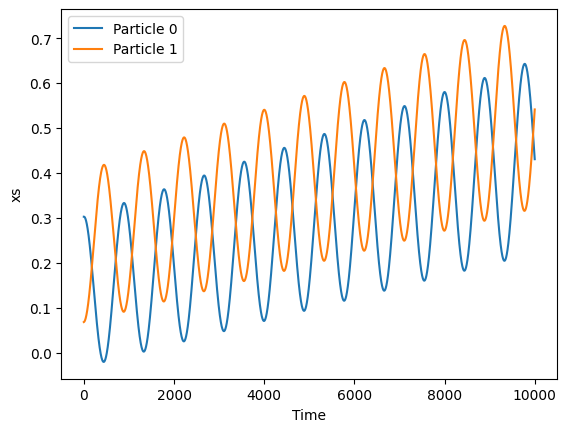

positions [[-0.33431046537643805, 0.4517008366048074], [-0.33432417766001105, 0.45169653931016096], [-0.3343211851465495, 0.45167553721847997], [-0.33430148760067874, 0.45163783009438974], [-0.33426508562226387, 0.45158341853775535], [-0.3342119806464216, 0.4515123039836936], [-0.33414217494349036, 0.4514244887025428], [-0.3340556716189583, 0.45131997579979133], [-0.33395247461335015, 0.4511987692159637], [-0.3338325887020715, 0.4510608737264656], [-0.33369601949521216, 0.45090629494138673], [-0.3335427734373071, 0.45073503930526215], [-0.3333728578070561, 0.45054711409679166], [-0.33318628071700157, 0.4503425274285176], [-0.33298305111316445, 0.45012128824646097], [-0.3327631787746387, 0.4498834063297157], [-0.3325266743131439, 0.4496288922900014], [-0.33227354917253654, 0.4493577575711746], [-0.3320038156282791, 0.44907001444869765], [-0.331717486786868, 0.44876567602906714], [-0.33141457658522006, 0.44844475624919966], [-0.3310950997900167, 0.4481072698757768], [-0.3307590719970075,

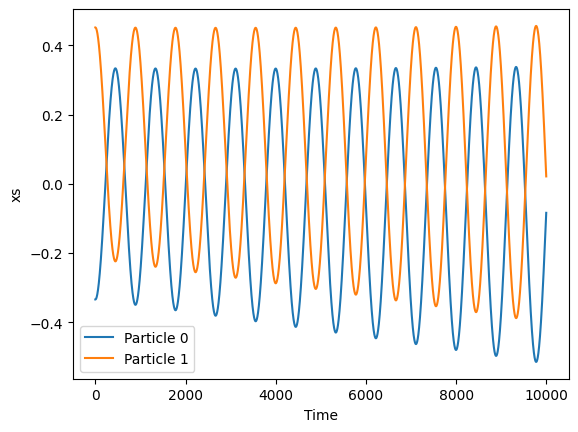

positions [[-0.1580321095096695, 0.4102618452094292], [-0.1579936050845446, 0.4102551936009827], [-0.15794321049012333, 0.4102366518232399], [-0.1578809268553065, 0.41020622100510146], [-0.15780675590350343, 0.4101639028699768], [-0.15772069995257545, 0.4101096997357272], [-0.15762276191474972, 0.4100436145145799], [-0.15751294529650336, 0.40996565071301194], [-0.15739125419841787, 0.40987581243160487], [-0.15725769331500375, 0.40977410436486916], [-0.15711226793449545, 0.4096605318010393], [-0.15695498393861676, 0.409535100621839], [-0.15678584780231627, 0.4093978173022169], [-0.15660486659347336, 0.40924868891005245], [-0.15641204797257444, 0.40908772310583197], [-0.1562074001923595, 0.40891492814229546], [-0.15599093209743922, 0.4087303128640536], [-0.15576265312388216, 0.40853388670717494], [-0.15552257329877264, 0.40832565969874385], [-0.15527070323973896, 0.4081056424563886], [-0.15500705415445193, 0.40787384618777994], [-0.15473163784009408, 0.40763028269010054], [-0.15444446668

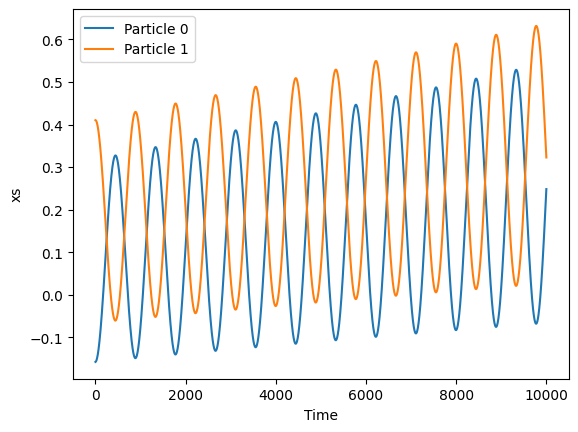

positions [[0.2521557791901602, -0.4221617591634771], [0.25214396543893314, -0.42219046561317036], [0.25211340853982434, -0.4222004289149819], [0.2520641080705163, -0.4221916486465942], [0.25199606454584905, -0.42216412532284725], [0.25190927941784097, -0.4221178603957595], [0.25180375507566327, -0.4220528562545021], [0.25167949484556734, -0.4219691162253265], [0.25153650299076524, -0.42186664457144474], [0.2513747847112635, -0.42174544649286333], [0.2511943461436498, -0.42160552812616997], [0.2509951943608331, -0.4214468965442736], [0.2507773373717368, -0.4212695597560976], [0.25054078412094494, -0.42107352670622605], [0.250285544488302, -0.4208588072745034], [0.25001162928846543, -0.42062541227558725], [0.24971905027041194, -0.4203733534584541], [0.24940782011689647, -0.42010264350585896], [0.24907795244386485, -0.4198132960337477], [0.24872946179981978, -0.4195053255906229], [0.2483623636651399, -0.41917874765686336], [0.24797667445135232, -0.4188335786439961], [0.24757241150035883,

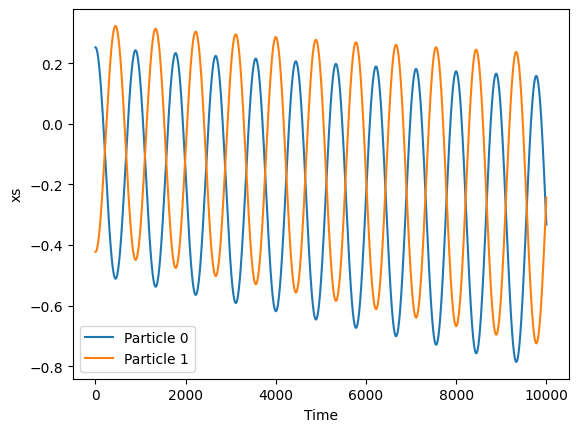

positions [[-0.10750921497835753, 0.38227207070992686], [-0.10746547092136652, 0.3822222944705846], [-0.10741369735113473, 0.3821644887180015], [-0.10735389660566957, 0.38209865579018504], [-0.10728607142445411, 0.3820247984266183], [-0.10721022494833016, 0.38194291976814304], [-0.10712636071936137, 0.381853023356823], [-0.10703448268067609, 0.3817551131357864], [-0.10693459517629032, 0.38164919344904935], [-0.10682670295091057, 0.3815352690413183], [-0.1067108111497166, 0.381413345057773], [-0.10658692531812425, 0.3812834270438294], [-0.10645505140152814, 0.38114552094488197], [-0.10631519574502439, 0.3809996331060269], [-0.1061673650931134, 0.38084577027176464], [-0.10601156658938257, 0.38068393958568253], [-0.10584780777616903, 0.38051414859011773], [-0.10567609659420255, 0.3803364052257999], [-0.10549644138222833, 0.3801507178314744], [-0.10530885087661003, 0.37995709514350484], [-0.10511333421091282, 0.3797555462954563], [-0.10490990091546652, 0.3795460808176587], [-0.104698560916

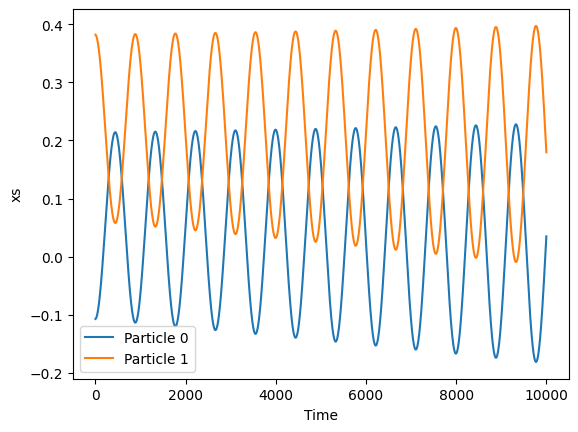

positions [[-0.31275660856416276, 0.07645911804545558], [-0.31276834341882453, 0.07644768729877681], [-0.3127743340865528, 0.07643051236516454], [-0.3127745805597449, 0.07640759323701607], [-0.3127690831180074, 0.07637893019393804], [-0.31275784232815673, 0.07634452380274684], [-0.312740859044205, 0.07630437491745458], [-0.31271813440733176, 0.07625848467924078], [-0.3126896698458412, 0.07620685451640967], [-0.31265546707510516, 0.07614948614433314], [-0.3126155280974918, 0.0760863815653793], [-0.31256985520227976, 0.0760175430688267], [-0.31251845096555786, 0.07594297323076427], [-0.3124613182501109, 0.0758626749139768], [-0.31239846020529083, 0.07577665126781616], [-0.31232988026687336, 0.07568490572805815], [-0.3122555821569008, 0.07558744201674505], [-0.3121755698835101, 0.07548426414201383], [-0.3120898477407468, 0.07537537639790999], [-0.31199842030836455, 0.07526078336418726], [-0.31190129245161063, 0.0751404899060928], [-0.31179846932099664, 0.07501450117413827], [-0.3116899563

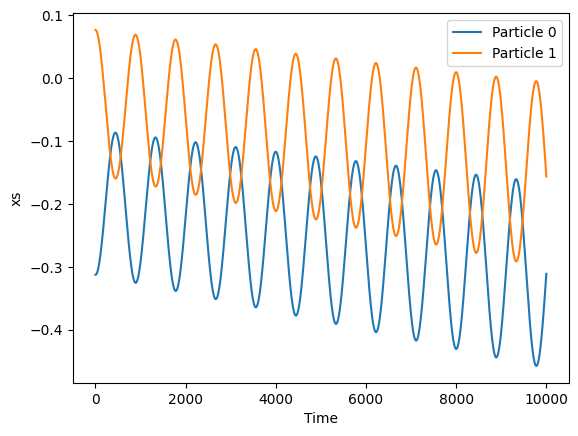

positions [[0.30931811539280163, -0.13963031783339164], [0.3093621434465943, -0.13960417523340807], [0.30939027572321387, -0.13956213685625143], [0.3094025117755241, -0.1395042022547854], [0.3093988519511774, -0.1394303717766625], [0.30937929739263753, -0.13934064656434644], [0.3093438500371621, -0.1392350285550948], [0.30929251261674534, -0.1391135204809018], [0.3092252886580214, -0.13897612586840163], [0.3091421824821276, -0.13882284903873163], [0.3090431992045283, -0.13865369510735606], [0.3089283447347985, -0.13846866998385007], [0.3087976257763686, -0.1382677803716439], [0.3086510498262283, -0.13805103376772734], [0.3084886251745919, -0.13781843846231473], [0.30831036090452324, -0.13757000353846985], [0.3081162668915213, -0.13730573887169165], [0.30790635380306586, -0.13702565512946], [0.30768063309812393, -0.13672976377074186], [0.3074391170266163, -0.13641807704545802], [0.3071818186288446, -0.13609060799391007], [0.30690875173487864, -0.13574737044616791], [0.3066199309639047, 

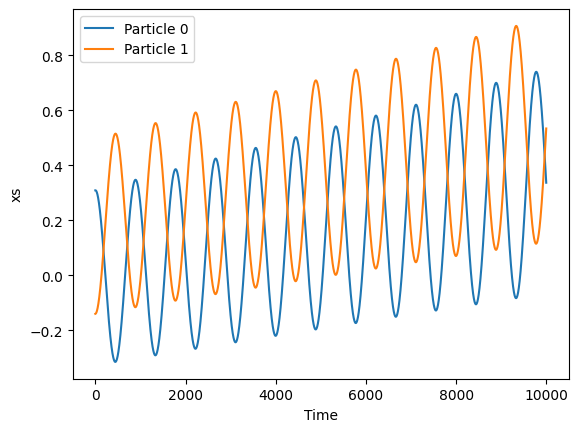

In [109]:
for i in range(10):
    plot_graph(df, i)